# 🐝 Honeybee vs Bumblebee Classification — Deep Learning
### Transfer Learning + Fine-Tuning with MobileNetV2

## 1. Imports & Configuration

In [1]:
!pip install jupyter_http_over_ws
!jupyter serverextension enable --py jupyter_http_over_ws

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 40.3 MB/s eta 0:00:00
Enabling: jupyter_http_over_ws
- Writing config: /root/.jupyter
    - Validating...
      jupyter_http_over_ws 0.0.7 OK


In [1]:
!pip install tensorflow

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
import pandas as pd

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [3]:
# ── Paths & Hyperparameters ──────────────────────────────────────
TRAIN_DIR   = '../data/processed/train'
TEST_DIR    = '../data/processed/test'
IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
SEED        = 42
AUTOTUNE    = tf.data.AUTOTUNE

## 2. Load Datasets

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
TRAIN_DIR = "/content/drive/MyDrive/data/processed/train"
TEST_DIR = "/content/drive/MyDrive/data/processed/test"

In [6]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='training',
    seed=SEED
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='validation',
    seed=SEED
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds_raw.class_names
print('Classes:', class_names)

Found 1323 files belonging to 2 classes.
Using 1059 files for training.
Found 1323 files belonging to 2 classes.
Using 264 files for validation.
Found 331 files belonging to 2 classes.
Classes: ['bumblebee', 'honeybee']


  Class                 Train     Test
  bumblebee               661      166
  honeybee                662      165
  TOTAL                  1323      331

  Batch size      : 32
  Batches / epoch : 34
  Image size      : (224, 224)


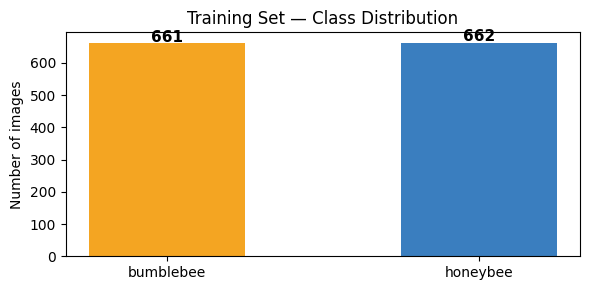

In [21]:
# ── Dataset Exploration ───────────────────────────────────────────
import pathlib

train_path = pathlib.Path(TRAIN_DIR)
test_path  = pathlib.Path(TEST_DIR)

print("=" * 50)
print(f"  {'Class':<18} {'Train':>8}   {'Test':>6}")
print("=" * 50)
total_train, total_test = 0, 0
for cls in class_names:
    tr = len(list(train_path.glob(f'{cls}/*')))
    te = len(list(test_path.glob(f'{cls}/*')))
    total_train += tr
    total_test  += te
    print(f"  {cls:<18} {tr:>8}   {te:>6}")
print("=" * 50)
print(f"  {'TOTAL':<18} {total_train:>8}   {total_test:>6}")
print(f"\n  Batch size      : {BATCH_SIZE}")
print(f"  Batches / epoch : {len(train_ds_raw)}")
print(f"  Image size      : {IMAGE_SIZE}")
print("=" * 50)

# Class distribution bar chart
counts = {cls: len(list(train_path.glob(f'{cls}/*'))) for cls in class_names}
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(counts.keys(), counts.values(),
              color=['#F4A522', '#3A7EBF'], width=0.5)
ax.set_title('Training Set — Class Distribution')
ax.set_ylabel('Number of images')
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + 5, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Data Augmentation & Preprocessing

> **Why augmentation?** With only ~1300 images, augmentation artificially expands the dataset and helps prevent overfitting by showing the model different variations of the same image.

In [7]:
# Augmentation layers (applied only during training)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),        # bees are never upside-down
    layers.RandomRotation(0.10),            # was 0.2 — less aggressive
    layers.RandomZoom(0.10),                # was 0.15 — less aggressive
    layers.RandomContrast(0.1),             # keep same
], name='data_augmentation')

# MobileNetV2 expects inputs scaled to [-1, 1]
def preprocess(image, label):
    return preprocess_input(image), label

def augment_and_preprocess(image, label):
    image = data_augmentation(image, training=True)
    return preprocess_input(image), label

train_ds = (train_ds_raw
            .cache()                                                   # ← cache RAW images first
            .map(augment_and_preprocess, num_parallel_calls=AUTOTUNE) # ← then augment freshly every epoch
            .prefetch(AUTOTUNE))
val_ds   = val_ds_raw.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds  = test_ds_raw.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

print('Datasets ready.')

Datasets ready.


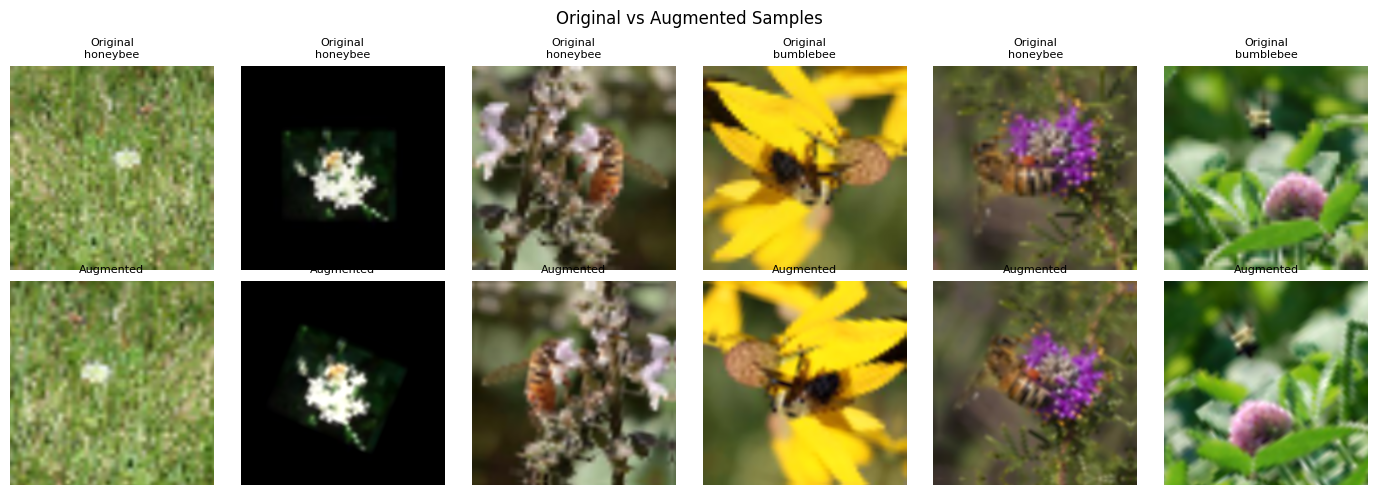

In [8]:
# Visualize original vs augmented samples
plt.figure(figsize=(14, 5))
for images, labels in train_ds_raw.take(1):
    for i in range(6):
        ax = plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(f'Original\n{class_names[labels[i]]}', fontsize=8)
        plt.axis('off')

        ax = plt.subplot(2, 6, i + 7)
        aug = data_augmentation(tf.expand_dims(images[i], 0), training=True)
        plt.imshow(aug[0].numpy().astype('uint8'))
        plt.title('Augmented', fontsize=8)
        plt.axis('off')

plt.suptitle('Original vs Augmented Samples', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Build the Model

**Architecture:**
```
Input (224×224×3)
  → MobileNetV2 backbone  ← pre-trained on ImageNet
  → GlobalAveragePooling2D
  → BatchNormalization
  → Dense(256, relu) → Dropout(0.4)
  → Dense(128, relu) → Dropout(0.3)
  → Dense(1, sigmoid)   ← binary output
```

> **Why sigmoid + 1 unit?** Binary classification. Outputs probability of class 1 (bumblebee). Threshold 0.5 → prediction.

In [9]:
def build_model(trainable_backbone=False, unfreeze_from_layer=None):
    """
    Build MobileNetV2-based transfer learning model.

    Args:
        trainable_backbone  : if True, backbone layers can be trained
        unfreeze_from_layer : layer name to start unfreezing from (fine-tuning)
    """
    backbone = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    backbone.trainable = trainable_backbone

    # Phase 2: selectively unfreeze top layers
    if trainable_backbone and unfreeze_from_layer:
        set_trainable = False
        for layer in backbone.layers:
            if layer.name == unfreeze_from_layer:
                set_trainable = True
            layer.trainable = set_trainable
        trainable_count = sum(1 for l in backbone.layers if l.trainable)
        print(f'Trainable backbone layers: {trainable_count}')

    inputs  = tf.keras.Input(shape=(224, 224, 3))
    x       = backbone(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs)

## 5. Phase 1 — Train Head Only (Backbone Frozen)

> The backbone weights are frozen. Only the Dense layers on top are trained. This prevents the randomly-initialized head from destroying ImageNet weights.

In [10]:
model = build_model(trainable_backbone=False)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,065 (10.01 MB)

 Trainable params: 363,521 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [11]:
# ── Class Weights — handle imbalanced dataset ─────────────────────
from sklearn.utils.class_weight import compute_class_weight

# Collect all training labels from the raw (un-augmented) dataset
all_labels = np.concatenate([y.numpy() for _, y in train_ds_raw])

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights_arr))

print("Class weights:")
for k, v in class_weight_dict.items():
    print(f"  {class_names[k]:<15} → {v:.4f}")

Class weights:
  bumblebee       → 0.9916
  honeybee        → 1.0086


In [12]:
callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_phase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1)
]

history1 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks_phase1,
    class_weight=class_weight_dict      # handles class imbalance
)

Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.6564 - auc: 0.6856 - loss: 0.7368
Epoch 1: val_accuracy improved from None to 0.65152, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.7110 - auc: 0.7613 - loss: 0.6564 - val_accuracy: 0.6515 - val_auc: 0.8818 - val_loss: 0.6281 - learning_rate: 0.0010
Epoch 2/30
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.7476 - auc: 0.8521 - loss: 0.5017
Epoch 2: val_accuracy improved from 0.65152 to 0.78409, saving model to best_model_phase1.keras

Epoch 2: finished saving model to best_model_phase1.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 289ms/step - accuracy: 0.7705 - auc: 0.8692 - loss: 0.4602 - val_accuracy: 0.7841 - val_auc: 0.8972 - val_loss: 0.4103 - learning_rate: 0.0010
Epoch 3/30
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.8033 - auc: 0.8866 - loss: 0.4309
Epoch 3: val_accuracy improved from 0.78409 to 0

## 6. Phase 2 — Fine-Tune Top Backbone Layers

> We unfreeze MobileNetV2 layers from `block_12_expand` onward (~30 layers). Using a very small learning rate (1e-5) to gently adapt these layers to bee-specific features without destroying ImageNet knowledge.

**Why fine-tune?** Frozen ImageNet features are generic (edges, textures). Fine-tuning adapts the top layers to learn bee-specific patterns like fuzz, stripes, and wing shapes.

In [13]:
FINE_TUNE_FROM = 'block_12_expand'   # unfreeze more layers than before

# ── Modify the SAME model in-place — do NOT rebuild ─────────────
# This preserves all BatchNorm statistics from Phase 1 training.
backbone = model.layers[1]   # MobileNetV2 is the 2nd layer
backbone.trainable = True

set_trainable = False
for layer in backbone.layers:
    if layer.name == FINE_TUNE_FROM:
        set_trainable = True
    layer.trainable = set_trainable

n_trainable = sum(1 for l in backbone.layers if l.trainable)
n_frozen    = sum(1 for l in backbone.layers if not l.trainable)
print(f"Backbone — Trainable layers: {n_trainable}  |  Frozen layers: {n_frozen}")

# MUST recompile after changing trainable flags
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

Backbone — Trainable layers: 47  |  Frozen layers: 107


In [14]:
callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_phase2.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss',
                      factor=0.5,       # was 0.3 — gentler decay
                      patience=6,       # was 5
                      min_lr=1e-7,      # was 1e-8
                      verbose=1)
]

history2 = model.fit(          # was model_ft.fit
    train_ds,
    epochs=40,
    validation_data=val_ds,
    callbacks=callbacks_phase2,
    class_weight=class_weight_dict  # handles class imbalance
)

Epoch 1/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.8088 - auc: 0.8948 - loss: 0.4431
Epoch 1: val_accuracy improved from None to 0.84091, saving model to best_model_phase2.keras

Epoch 1: finished saving model to best_model_phase2.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 57s 905ms/step - accuracy: 0.8074 - auc: 0.8921 - loss: 0.4399 - val_accuracy: 0.8409 - val_auc: 0.9256 - val_loss: 0.3593 - learning_rate: 1.0000e-05
Epoch 2/40
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.8261 - auc: 0.9065 - loss: 0.4034
Epoch 2: val_accuracy did not improve from 0.84091
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 333ms/step - accuracy: 0.8225 - auc: 0.9077 - loss: 0.4002 - val_accuracy: 0.8409 - val_auc: 0.9282 - val_loss: 0.3549 - learning_rate: 1.0000e-05
Epoch 3/40
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.8210 - auc: 0.8985 - loss: 0.4294
Epoch 3: val_accuracy did not improve from 0.84091
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 322ms/step - accuracy: 0.8300 - auc: 0.9055 - loss: 0.4049 

## 7. Training Curves

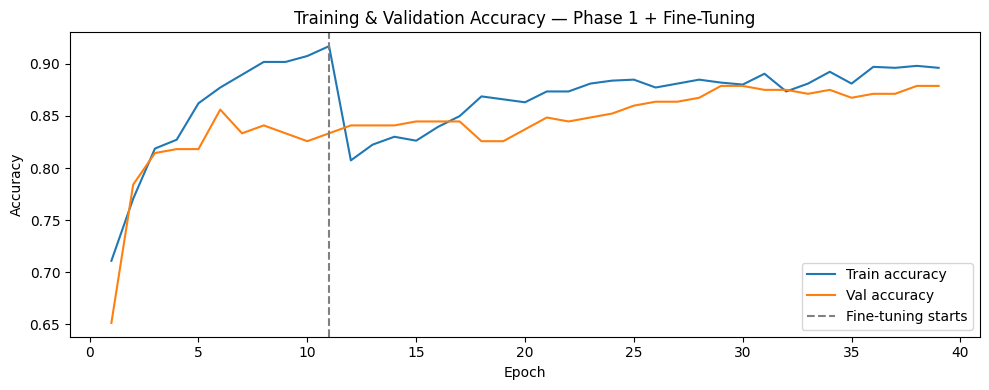

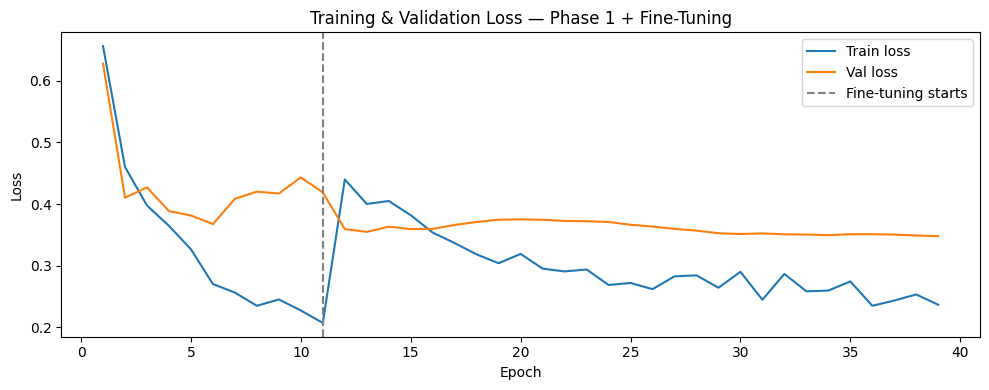

In [15]:
def plot_history(h1, h2, metric='accuracy'):
    """Plot combined Phase 1 + Phase 2 training curves."""
    combined     = h1.history[metric]     + h2.history[metric]
    combined_val = h1.history[f'val_{metric}'] + h2.history[f'val_{metric}']
    epochs_total = range(1, len(combined) + 1)
    phase2_start = len(h1.history[metric])

    plt.figure(figsize=(10, 4))
    plt.plot(epochs_total, combined,     label=f'Train {metric}')
    plt.plot(epochs_total, combined_val, label=f'Val {metric}')
    plt.axvline(phase2_start, color='gray', linestyle='--', label='Fine-tuning starts')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.title(f'Training & Validation {metric.capitalize()} — Phase 1 + Fine-Tuning')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history1, history2, 'accuracy')
plot_history(history1, history2, 'loss')

                    Phase                               Strategy  Epochs run Best val acc Best val AUC     Gain
Phase 1 — Frozen backbone               Head layers trained only          11       0.8561       0.9218 baseline
     Phase 2 — Fine-tuned Backbone unfrozen from block_12_expand          28       0.8788       0.9367   +2.27%


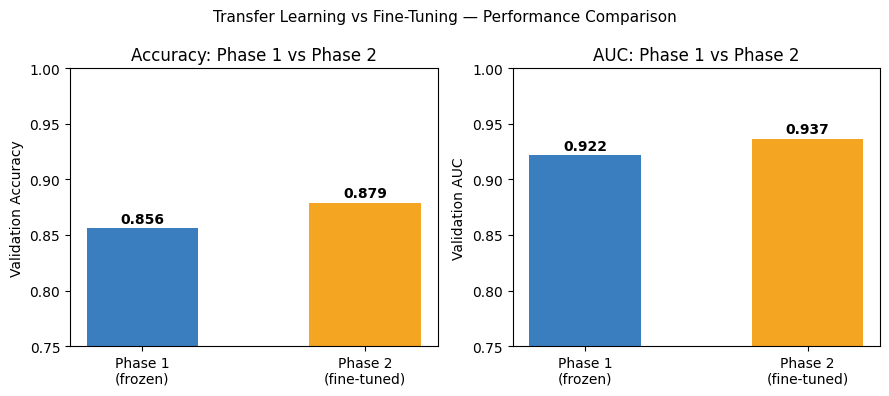

In [16]:
# ── Phase 1 vs Phase 2 — Summary Comparison ──────────────────────
p1_best_acc = max(history1.history['val_accuracy'])
p1_best_auc = max(history1.history['val_auc'])
p2_best_acc = max(history2.history['val_accuracy'])
p2_best_auc = max(history2.history['val_auc'])
p1_epochs   = len(history1.history['val_accuracy'])
p2_epochs   = len(history2.history['val_accuracy'])

summary_df = pd.DataFrame({
    'Phase'       : ['Phase 1 — Frozen backbone',
                     'Phase 2 — Fine-tuned'],
    'Strategy'    : ['Head layers trained only',
                     f'Backbone unfrozen from {FINE_TUNE_FROM}'],
    'Epochs run'  : [p1_epochs, p2_epochs],
    'Best val acc': [f'{p1_best_acc:.4f}', f'{p2_best_acc:.4f}'],
    'Best val AUC': [f'{p1_best_auc:.4f}', f'{p2_best_auc:.4f}'],
    'Gain'        : ['baseline',
                     f'+{(p2_best_acc - p1_best_acc) * 100:.2f}%'],
})
print(summary_df.to_string(index=False))

# Side-by-side bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
phases = ['Phase 1\n(frozen)', 'Phase 2\n(fine-tuned)']
colors = ['#3A7EBF', '#F4A522']

ax1.bar(phases, [p1_best_acc, p2_best_acc], color=colors, width=0.5)
ax1.set_ylim(0.75, 1.0)
ax1.set_ylabel('Validation Accuracy')
ax1.set_title('Accuracy: Phase 1 vs Phase 2')
for i, v in enumerate([p1_best_acc, p2_best_acc]):
    ax1.text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

ax2.bar(phases, [p1_best_auc, p2_best_auc], color=colors, width=0.5)
ax2.set_ylim(0.75, 1.0)
ax2.set_ylabel('Validation AUC')
ax2.set_title('AUC: Phase 1 vs Phase 2')
for i, v in enumerate([p1_best_auc, p2_best_auc]):
    ax2.text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Transfer Learning vs Fine-Tuning — Performance Comparison',
             fontsize=11)
plt.tight_layout()
plt.show()

## 8. Evaluate on Test Set

In [17]:
y_true, y_prob = [], []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)   # was model_ft
    y_prob.extend(probs.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

test_acc = np.mean(y_pred == y_true)
print(f'Test Accuracy: {test_acc:.4f}\n')
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

Test Accuracy: 0.8550

Classification Report:
              precision    recall  f1-score   support

   bumblebee       0.89      0.81      0.85       166
    honeybee       0.83      0.90      0.86       165

    accuracy                           0.85       331
   macro avg       0.86      0.86      0.85       331
weighted avg       0.86      0.85      0.85       331



## 9. Confusion Matrix

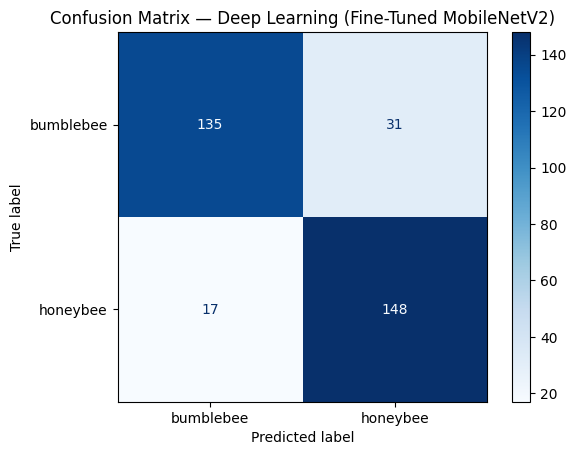

In [18]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Deep Learning (Fine-Tuned MobileNetV2)')
plt.show()

## 10. ROC Curve

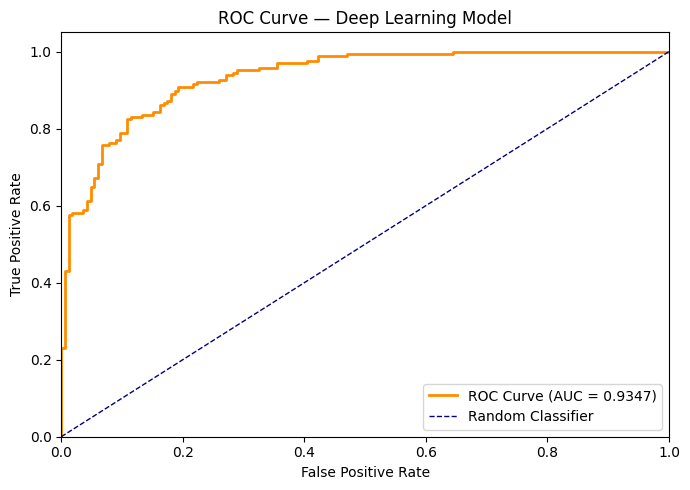

In [19]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Deep Learning Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 11. Visualize Predictions on Test Images

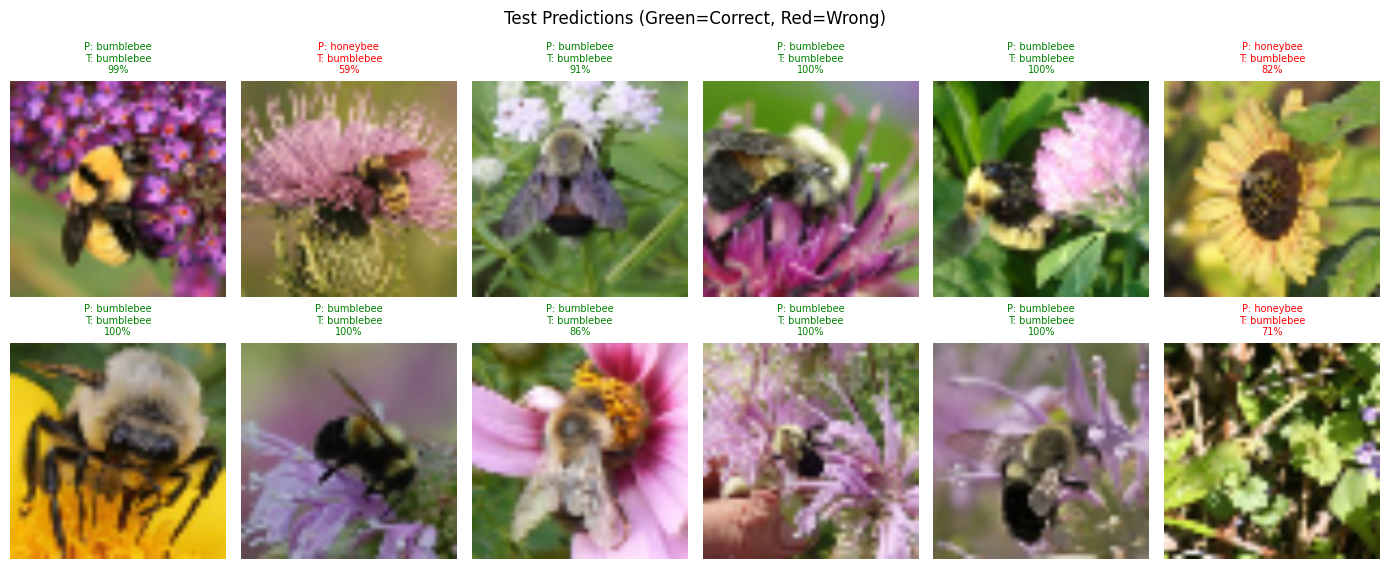

In [20]:
plt.figure(figsize=(14, 6))
for images, labels in test_ds_raw.take(1):
    preprocessed = preprocess_input(tf.cast(images, tf.float32))
    probs = model.predict(preprocessed, verbose=0).flatten()

    for i in range(min(12, len(images))):
        plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        pred_label = class_names[int(probs[i] >= 0.5)]
        true_label = class_names[labels[i]]
        color = 'green' if pred_label == true_label else 'red'
        confidence = probs[i] if int(probs[i] >= 0.5) == 1 else 1 - probs[i]
        plt.title(f'P: {pred_label}\nT: {true_label}\n{confidence:.0%}',
                  fontsize=7, color=color)
        plt.axis('off')

plt.suptitle('Test Predictions (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 12. ResNet50 — Second Backbone for Comparison

> **Why ResNet50?** ResNet50 uses skip connections (residual connections) that solve the vanishing gradient problem, allowing 50 layers to train effectively. It has 25M parameters vs MobileNetV2's 3.4M — a fundamentally different architecture that trades efficiency for accuracy.
>
> We apply the exact same two-phase training strategy to ensure a fair comparison.

In [22]:
# ── ResNet50 needs its own preprocessing function ────────────────
# Each backbone has a specific pixel scaling it was trained with.
# MobileNetV2 expects [-1, 1]. ResNet50 expects BGR mean-subtracted.
# Never mix them — using wrong preprocessing silently hurts accuracy.

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

def resnet_preprocess_fn(image, label):
    return resnet_preprocess(tf.cast(image, tf.float32)), label

def resnet_augment_fn(image, label):
    image = data_augmentation(image, training=True)
    return resnet_preprocess(tf.cast(image, tf.float32)), label

train_ds_r50 = (train_ds_raw
                .cache()
                .map(resnet_augment_fn, num_parallel_calls=AUTOTUNE)
                .prefetch(AUTOTUNE))

val_ds_r50   = (val_ds_raw
                .map(resnet_preprocess_fn, num_parallel_calls=AUTOTUNE)
                .cache()
                .prefetch(AUTOTUNE))

test_ds_r50  = (test_ds_raw
                .map(resnet_preprocess_fn, num_parallel_calls=AUTOTUNE)
                .cache()
                .prefetch(AUTOTUNE))

print("ResNet50 datasets ready.")

ResNet50 datasets ready.


In [23]:
# ── Build ResNet50 model ──────────────────────────────────────────
# Identical head architecture as MobileNetV2 for a fair comparison:
# GAP → BN → Dense(256) → Dropout(0.4) → Dense(128) → Dropout(0.3) → sigmoid

def build_resnet50_model():
    backbone_r50 = ResNet50(
        input_shape=(224, 224, 3),
        include_top=False,       # remove ResNet's 1000-class ImageNet head
        weights='imagenet'       # use pretrained weights
    )
    backbone_r50.trainable = False   # freeze for Phase 1

    inputs  = tf.keras.Input(shape=(224, 224, 3))
    x       = backbone_r50(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model   = tf.keras.Model(inputs, outputs)
    return model, backbone_r50

model_r50, backbone_r50 = build_resnet50_model()

# Parameter breakdown
total_r50     = model_r50.count_params()
trainable_r50 = sum(tf.size(w).numpy() for w in model_r50.trainable_weights)
frozen_r50    = total_r50 - trainable_r50

print(f"{'='*45}")
print(f"  ResNet50 Architecture Summary")
print(f"{'='*45}")
print(f"  Total parameters   : {total_r50:>10,}")
print(f"  Trainable (head)   : {trainable_r50:>10,}")
print(f"  Frozen (backbone)  : {frozen_r50:>10,}")
print(f"  Frozen %           : {frozen_r50/total_r50*100:>9.1f}%")
print(f"{'='*45}")

model_r50.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  ResNet50 Architecture Summary
  Total parameters   : 24,153,473
  Trainable (head)   :    561,665
  Frozen (backbone)  : 23,591,808
  Frozen %           :      97.7%


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,153,473 (92.14 MB)

 Trainable params: 561,665 (2.14 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

### Phase 1 — Train Head Only (ResNet50 Backbone Frozen)

> Same strategy as MobileNetV2 Phase 1: backbone frozen, only the Dense classification head trains. This protects the 25M pretrained parameters from being destroyed by random head gradients.

In [24]:
model_r50.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks_r50_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_r50_phase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1)
]

print("=== ResNet50 — Phase 1: Frozen backbone ===")
history_r50_p1 = model_r50.fit(
    train_ds_r50,
    epochs=30,
    validation_data=val_ds_r50,
    callbacks=callbacks_r50_p1,
    class_weight=class_weight_dict      # same class weights as MobileNetV2
)

=== ResNet50 — Phase 1: Frozen backbone ===
Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 985ms/step - accuracy: 0.6324 - auc: 0.6980 - loss: 0.7285
Epoch 1: val_accuracy improved from None to 0.79545, saving model to best_r50_phase1.keras

Epoch 1: finished saving model to best_r50_phase1.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.7177 - auc: 0.7903 - loss: 0.6304 - val_accuracy: 0.7955 - val_auc: 0.8853 - val_loss: 0.4309 - learning_rate: 0.0010
Epoch 2/30
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.8242 - auc: 0.9144 - loss: 0.4005
Epoch 2: val_accuracy improved from 0.79545 to 0.85606, saving model to best_r50_phase1.keras

Epoch 2: finished saving model to best_r50_phase1.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 29s 406ms/step - accuracy: 0.8366 - auc: 0.9145 - loss: 0.3900 - val_accuracy: 0.8561 - val_auc: 0.9332 - val_loss: 0.3346 - learning_rate: 0.0010
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.8324 - auc: 0.9193 - loss: 0.3816
Epoch 3: val

### Phase 2 — Fine-Tune Top ResNet50 Layers

> We unfreeze ResNet50 from `conv5_block1_1_conv` onward — this is the last residual block (conv5). Using the same 1e-5 learning rate to gently adapt high-level features to bee-specific patterns.
>
> **Why conv5_block1_1_conv?** ResNet50 is organised into 5 convolutional stages. The final stage (conv5) learns the most task-specific high-level features — these are the ones most worth adapting to bees. Earlier stages learn generic edges and textures which are already correct.

In [25]:
# ── ResNet50 Phase 2: modify in-place ────────────────────────────
FINE_TUNE_FROM_R50 = 'conv5_block1_1_conv'   # last residual block of ResNet50

backbone_r50.trainable = True

set_trainable = False
for layer in backbone_r50.layers:
    if layer.name == FINE_TUNE_FROM_R50:
        set_trainable = True
    layer.trainable = set_trainable

n_trainable_r50 = sum(1 for l in backbone_r50.layers if l.trainable)
n_frozen_r50    = sum(1 for l in backbone_r50.layers if not l.trainable)
print(f"ResNet50 — Trainable layers : {n_trainable_r50}")
print(f"ResNet50 — Frozen layers    : {n_frozen_r50}")

# MUST recompile after changing trainable flags
model_r50.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks_r50_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_r50_phase2.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=6, min_lr=1e-7, verbose=1)
]

print("\n=== ResNet50 — Phase 2: Fine-tuning ===")
history_r50_p2 = model_r50.fit(
    train_ds_r50,
    epochs=40,
    validation_data=val_ds_r50,
    callbacks=callbacks_r50_p2,
    class_weight=class_weight_dict
)

ResNet50 — Trainable layers : 32
ResNet50 — Frozen layers    : 143

=== ResNet50 — Phase 2: Fine-tuning ===
Epoch 1/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.8729 - auc: 0.9468 - loss: 0.3157
Epoch 1: val_accuracy improved from None to 0.85227, saving model to best_r50_phase2.keras

Epoch 1: finished saving model to best_r50_phase2.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8716 - auc: 0.9480 - loss: 0.3029 - val_accuracy: 0.8523 - val_auc: 0.9551 - val_loss: 0.3005 - learning_rate: 1.0000e-05
Epoch 2/40
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.8896 - auc: 0.9560 - loss: 0.2790
Epoch 2: val_accuracy improved from 0.85227 to 0.85606, saving model to best_r50_phase2.keras

Epoch 2: finished saving model to best_r50_phase2.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 446ms/step - accuracy: 0.9046 - auc: 0.9647 - loss: 0.2415 - val_accuracy: 0.8561 - val_auc: 0.9570 - val_loss: 0.2965 - learning_rate: 1.0000e-05
Epoch 3/40
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s

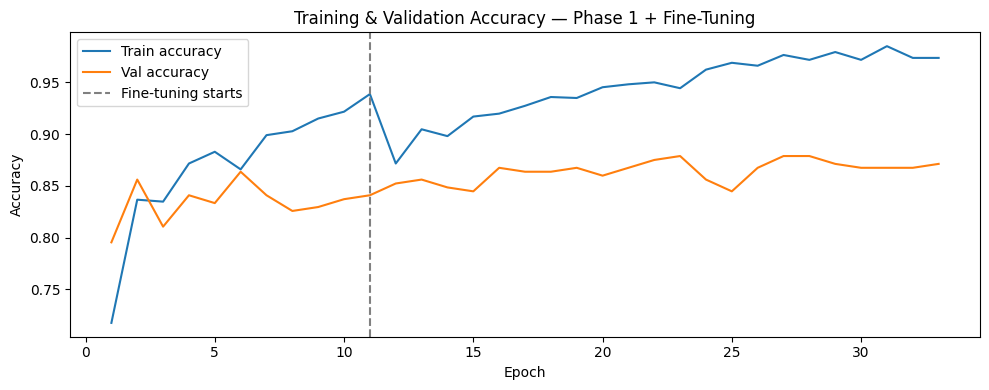

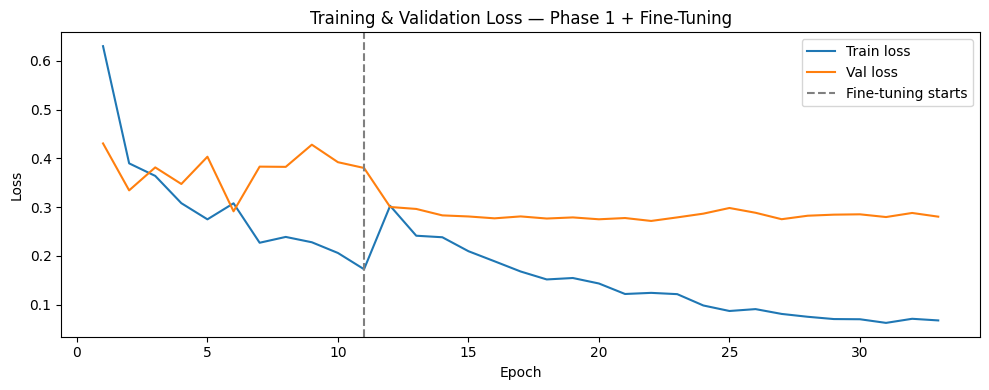

In [26]:
# ── ResNet50 Training Curves ──────────────────────────────────────
plot_history(history_r50_p1, history_r50_p2, 'accuracy')
plot_history(history_r50_p1, history_r50_p2, 'loss')

ResNet50 Test Accuracy : 0.9094

ResNet50 Classification Report:
              precision    recall  f1-score   support

   bumblebee       0.93      0.89      0.91       166
    honeybee       0.89      0.93      0.91       165

    accuracy                           0.91       331
   macro avg       0.91      0.91      0.91       331
weighted avg       0.91      0.91      0.91       331



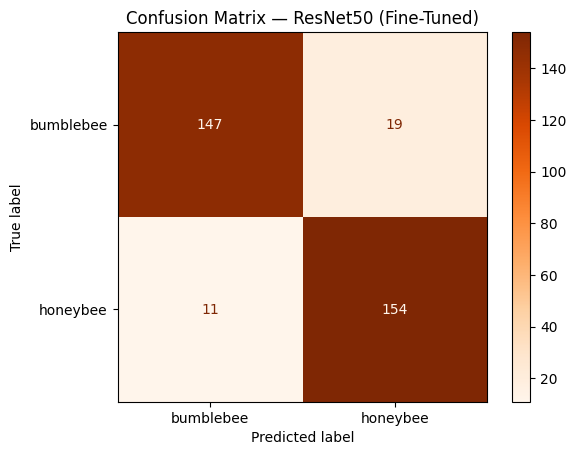

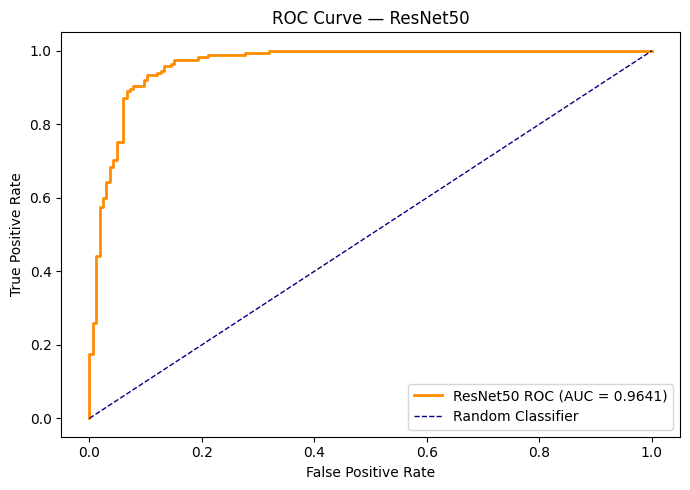

In [27]:
# ── ResNet50 Test Set Evaluation ─────────────────────────────────
y_prob_r50 = model_r50.predict(test_ds_r50, verbose=0).flatten()
y_pred_r50 = (y_prob_r50 >= 0.5).astype(int)

r50_test_acc = np.mean(y_pred_r50 == y_true)
print(f"ResNet50 Test Accuracy : {r50_test_acc:.4f}\n")
print("ResNet50 Classification Report:")
print(classification_report(y_true, y_pred_r50, target_names=class_names))

# Confusion matrix
cm_r50   = confusion_matrix(y_true, y_pred_r50)
disp_r50 = ConfusionMatrixDisplay(cm_r50, display_labels=class_names)
disp_r50.plot(cmap='Oranges')
plt.title('Confusion Matrix — ResNet50 (Fine-Tuned)')
plt.show()

# ROC curve
from sklearn.metrics import roc_curve, auc
fpr_r50, tpr_r50, _ = roc_curve(y_true, y_prob_r50)
r50_auc_score = auc(fpr_r50, tpr_r50)

plt.figure(figsize=(7, 5))
plt.plot(fpr_r50, tpr_r50, color='darkorange', lw=2,
         label=f'ResNet50 ROC (AUC = {r50_auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--',
         label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ResNet50')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 13. Final Comparison: MobileNetV2 vs ResNet50

  FINAL BACKBONE COMPARISON
      Model Parameters                Architecture P1 best val acc P2 best val acc Test accuracy Test AUC
MobileNetV2       3.4M    Depthwise separable conv          0.8561          0.8788        0.8550   0.9347
   ResNet50        25M Skip connections (residual)          0.8636          0.8788        0.9094   0.9641


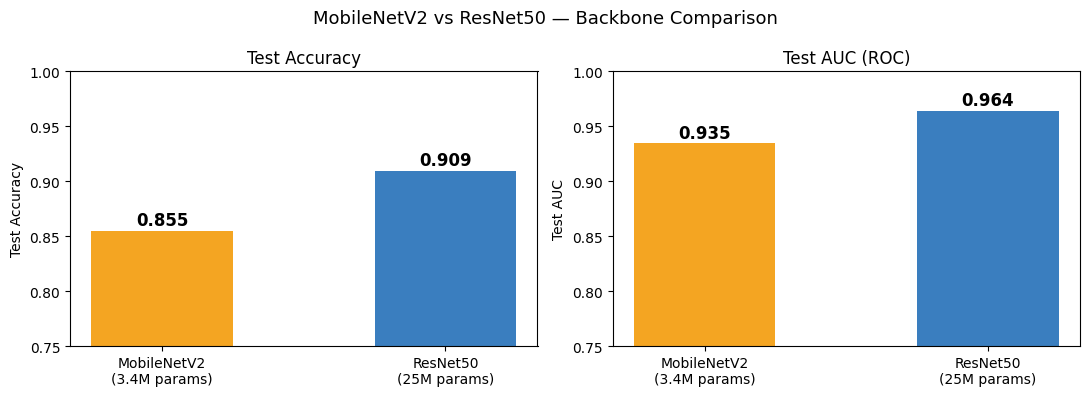

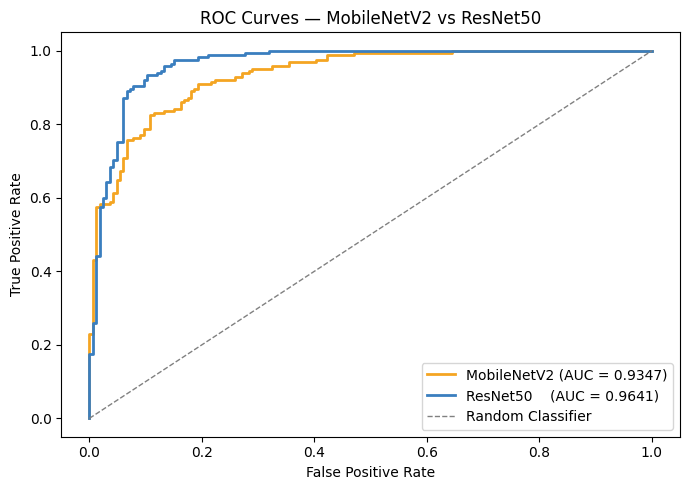

In [28]:
# ── Full comparison: MobileNetV2 vs ResNet50 ─────────────────────

# MobileNetV2 test metrics (already computed in Cell 26)
from sklearn.metrics import roc_curve, auc as sk_auc
fpr_m, tpr_m, _ = roc_curve(y_true, y_prob)
mobilenet_auc_score = sk_auc(fpr_m, tpr_m)
mobilenet_test_acc  = np.mean(y_pred == y_true)

# Summary table
comparison_df = pd.DataFrame({
    'Model'           : ['MobileNetV2', 'ResNet50'],
    'Parameters'      : ['3.4M', '25M'],
    'Architecture'    : ['Depthwise separable conv', 'Skip connections (residual)'],
    'P1 best val acc' : [f'{max(history1.history["val_accuracy"]):.4f}',
                         f'{max(history_r50_p1.history["val_accuracy"]):.4f}'],
    'P2 best val acc' : [f'{max(history2.history["val_accuracy"]):.4f}',
                         f'{max(history_r50_p2.history["val_accuracy"]):.4f}'],
    'Test accuracy'   : [f'{mobilenet_test_acc:.4f}', f'{r50_test_acc:.4f}'],
    'Test AUC'        : [f'{mobilenet_auc_score:.4f}', f'{r50_auc_score:.4f}'],
})

print("=" * 75)
print("  FINAL BACKBONE COMPARISON")
print("=" * 75)
print(comparison_df.to_string(index=False))
print("=" * 75)

# ── Bar chart: accuracy ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
models = ['MobileNetV2\n(3.4M params)', 'ResNet50\n(25M params)']
accs   = [mobilenet_test_acc, r50_test_acc]
aucs   = [mobilenet_auc_score, r50_auc_score]
colors = ['#F4A522', '#3A7EBF']

axes[0].bar(models, accs, color=colors, width=0.5)
axes[0].set_ylim(0.75, 1.0)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test Accuracy')
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center',
                 fontsize=12, fontweight='bold')

axes[1].bar(models, aucs, color=colors, width=0.5)
axes[1].set_ylim(0.75, 1.0)
axes[1].set_ylabel('Test AUC')
axes[1].set_title('Test AUC (ROC)')
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center',
                 fontsize=12, fontweight='bold')

plt.suptitle('MobileNetV2 vs ResNet50 — Backbone Comparison', fontsize=13)
plt.tight_layout()
plt.show()

# ── Overlay ROC curves ────────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(fpr_m,   tpr_m,   color='#F4A522', lw=2,
         label=f'MobileNetV2 (AUC = {mobilenet_auc_score:.4f})')
plt.plot(fpr_r50, tpr_r50, color='#3A7EBF', lw=2,
         label=f'ResNet50    (AUC = {r50_auc_score:.4f})')
plt.plot([0, 1],  [0, 1],  color='gray',    lw=1, linestyle='--',
         label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — MobileNetV2 vs ResNet50')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()